# BeeBright — Trained Intent Classifier (Task 32, Part 2)

This notebook trains a **text classifier** that predicts a BeeBright chatbot *intent*
label (e.g. `view_grades`, `raise_concern`, `payment_status`) from a raw user message,
in English, Filipino, or Taglish.

**What this model is — and is not:**
- It is an *intent-detection* layer only. Given a message, it outputs `{intent, confidence}`.
- It does **not** generate reply text, and it never touches the database. The actual
  answer still comes from `aiResponseDatasets.js` or the existing grounded DB lookups in
  the Node.js backend, exactly as today.
- It runs alongside the existing weighted-keyword matcher (Task 19/20) as an
  **additional signal with a fallback** — not a replacement. If its confidence is too
  low, or the service is unreachable, the Node backend falls back to the keyword
  matcher untouched (Part 4).

**Pipeline:** `pandas` (load the 4 role-based training CSVs) → `TfidfVectorizer`
(turn text into numeric features) → `LogisticRegression` / `LinearSVC` (learn which
features predict which intent) → save the fitted vectorizer + classifier for the
Flask microservice built in Part 3.


In [1]:

import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("pandas       ", pd.__version__)
print("scikit-learn ", sklearn.__version__)
print("numpy        ", np.__version__)
print("matplotlib   ", matplotlib.__version__)
print("python       ", platform.python_version())

DATA_DIR = Path("..") / "data"
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42


pandas        3.0.0
scikit-learn  1.8.0
numpy         2.4.2
matplotlib    3.11.1
python        3.14.2


## 1. Load the training data

Four CSVs, one per role pool (`public`, `student_parent`, `tutor`, `admin`), each with
columns `user_query, intent, role, requires_login`. Every English row in the source
drafts was expanded with Filipino and Taglish phrasings of the same question (Part 1),
so the vectorizer sees real multilingual variety per intent, not just English.

`role` and `requires_login` are **not** fed into the classifier — per Task 32 Part 1.3
they exist for *routing after classification* (which the Node backend already does via
the requester's authenticated role), not for training the text model itself. They are
kept in the dataframe for the class-balance check below, then dropped before
vectorizing.


In [2]:

csv_files = sorted(DATA_DIR.glob("*_users_expanded.csv"))
print(f"Found {len(csv_files)} training files:")
for f in csv_files:
    print(" -", f.name)

frames = [pd.read_csv(f, encoding="utf-8-sig") for f in csv_files]
raw = pd.concat(frames, ignore_index=True)
print(f"\nCombined: {len(raw)} rows across {raw['role'].nunique()} role pools, "
      f"{raw['intent'].nunique()} distinct intents.")
raw.head(8)


Found 4 training files:
 - admin_users_expanded.csv
 - public_users_expanded.csv
 - student_parent_users_expanded.csv
 - tutor_users_expanded.csv

Combined: 2566 rows across 4 role pools, 130 distinct intents.


,user_query,intent,role,requires_login
0,How many tutors are registered?,tutor_count,admin,yes
1,How many tutors are in the system?,tutor_count,admin,yes
2,Ilang tutors ang registered?,tutor_count,admin,yes
3,Can I see the total tutor count?,tutor_count,admin,yes
4,What is the current number of tutors?,tutor_count,admin,yes
5,Ilang tutor accounts ang meron?,tutor_count,admin,yes
6,Can you help me with this: how many tutors are...,tutor_count,admin,yes
7,Quick question: how many tutors are in the sys...,tutor_count,admin,yes


## 2. Clean the data

Two checks matter before training:

1. **Label conflicts** — the same `user_query` text mapped to two *different* intents
   would confuse the classifier (it can't learn a consistent mapping). The task brief
   says these were already fixed across the 4 files; we verify that here rather than
   assuming it.
2. **Cross-file duplicates** — a handful of intents genuinely apply to more than one
   role with identical phrasing (e.g. `raise_concern`, `ticket_status`, `child_safety`,
   `refund_policy` are asked the same way by students, tutors, and admins alike). Those
   rows are exact repeats of the same `(user_query → intent)` pair. Left in, the *same*
   sentence could land in both the train split and the test split, letting the model
   "memorize" the answer instead of generalizing — so we deduplicate on `user_query`
   before splitting.


In [3]:

conflict_counts = raw.groupby("user_query")["intent"].nunique()
conflicts = conflict_counts[conflict_counts > 1]
print(f"Rows where the same text maps to >1 intent: {len(conflicts)}")
assert len(conflicts) == 0, "Label conflicts found — fix the source CSVs before training."
print("No label conflicts. Good.")

before = len(raw)
df = raw.drop_duplicates(subset=["user_query"]).reset_index(drop=True)
print(f"Deduplicated on user_query: {before} -> {len(df)} rows "
      f"({before - len(df)} cross-role repeats removed).")

class_counts = df["intent"].value_counts()
print(f"\n{df['intent'].nunique()} intents, "
      f"{class_counts.min()} to {class_counts.max()} examples per intent "
      f"(mean {class_counts.mean():.1f}).")
class_counts.tail(10)


Rows where the same text maps to >1 intent: 0
No label conflicts. Good.
Deduplicated on user_query: 2566 -> 2356 rows (210 cross-role repeats removed).

130 intents, 18 to 28 examples per intent (mean 18.1).


intent
distress_detection       18
student_safety           18
student_discussion       18
tutor_access             18
other_tutor_data         18
availability_status      18
attendance_history       18
student_progress         18
my_tickets               18
tutor_wellbeing_check    18
Name: count, dtype: int64

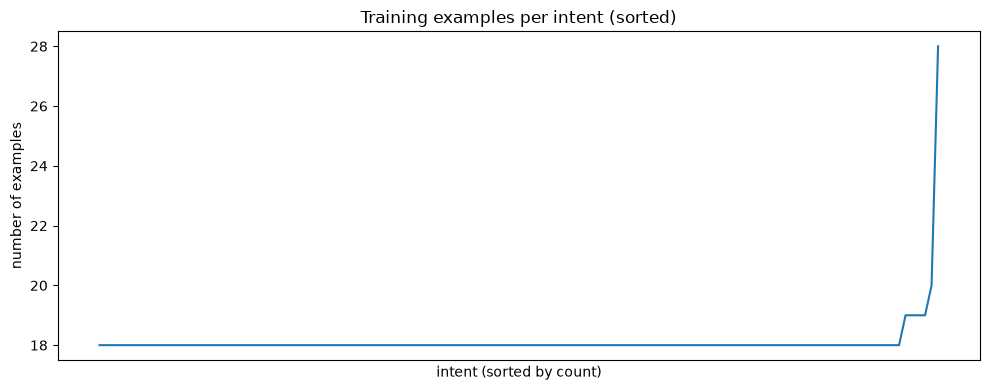

Smallest class has 18 examples — comfortable for an 80/20 stratified split (every class still appears in both train and test).


In [4]:

fig, ax = plt.subplots(figsize=(10, 4))
class_counts.sort_values().plot(kind="line", ax=ax)
ax.set_title("Training examples per intent (sorted)")
ax.set_xlabel("intent (sorted by count)")
ax.set_ylabel("number of examples")
ax.set_xticks([])
plt.tight_layout()
plt.savefig(MODELS_DIR / "class_balance.png", dpi=110)
plt.show()
print(f"Smallest class has {class_counts.min()} examples — comfortable for an 80/20 "
      f"stratified split (every class still appears in both train and test).")


## 3. Train / test split (80 / 20, stratified)

`stratify=y` keeps each intent's 80/20 proportion consistent across both splits —
without it, a rare intent could end up entirely in the training set (or entirely in
the test set), which would make the accuracy number below meaningless for that class.


In [5]:

X_text = df["user_query"].values
y = df["intent"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train_text)} examples   Test: {len(X_test_text)} examples")


Train: 1884 examples   Test: 472 examples


## 4. Vectorize with TF-IDF

`TfidfVectorizer` turns each message into a vector of word weights: a word gets a
**high** weight in a message if it appears often *there* but *rarely* across the rest
of the training set (so it's distinctive of that message's topic), and a **low** weight
if it's common everywhere (e.g. "the", "ang", "ko"). This is purely frequency-based —
it treats English, Filipino, and Taglish words the same way, with no
language-specific handling needed at this stage.

- `ngram_range=(1, 2)` — includes both single words *and* two-word phrases ("day off",
  "hindi ko") as features, since short phrases carry more of the intent than single
  words often do here.
- `min_df=1` — keep every term; the dataset is already small enough (2.3k rows) that
  pruning rare terms would throw away exactly the distinguishing words for the
  smaller intents.
- `sublinear_tf=True` — dampens the effect of a word repeated many times in one
  message, which matters for the short, template-style phrasings in this dataset
  ("Can you help me with this: ...", "Please tell me ... ??").


In [6]:

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    lowercase=True,
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(f"Vocabulary size: {len(vectorizer.vocabulary_)} terms")
print(f"Train matrix: {X_train.shape}   Test matrix: {X_test.shape}")


Vocabulary size: 2966 terms
Train matrix: (1884, 2966)   Test matrix: (472, 2966)


## 5. Train two classifiers and compare

- **LogisticRegression** — learns a weight per (word, intent) pair; `predict_proba`
  gives a genuine probability per intent, which is exactly the `confidence` score the
  Flask endpoint needs to return (Part 3) so the Node backend can decide whether to
  trust the prediction.
- **LinearSVC** — a linear support-vector machine; often edges out logistic regression
  on small, high-dimensional text problems like this one, but its raw output is a
  *distance from the decision boundary*, not a probability.

Both get evaluated at `max_iter=2000` (this dataset is small; more iterations makes sure
each model actually converges).


In [7]:

logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_acc = accuracy_score(y_test, logreg_pred)

svc = LinearSVC(max_iter=5000, random_state=RANDOM_STATE)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
svc_acc = accuracy_score(y_test, svc_pred)

print(f"LogisticRegression test accuracy: {logreg_acc:.4f}  ({(logreg_pred == y_test).sum()}/{len(y_test)} correct)")
print(f"LinearSVC           test accuracy: {svc_acc:.4f}  ({(svc_pred == y_test).sum()}/{len(y_test)} correct)")


LogisticRegression test accuracy: 0.9195  (434/472 correct)
LinearSVC           test accuracy: 0.9809  (463/472 correct)


### A real problem: LinearSVC wins clearly, but has no usable confidence score

With 129 intents and ~18 examples each, `LogisticRegression`'s softmax spreads its
probability mass thin — its own accuracy is markedly lower than `LinearSVC`'s here, and
(checked in §7 below) its `predict_proba` values stay so low, for correct *and*
incorrect predictions alike, that no reasonable threshold could separate them. Shipping
it as-is would mean the Flask service almost never clears the confidence bar, so the
Node backend would fall back to the keyword matcher on nearly every message — the
classifier would exist but do nothing.

`LinearSVC` has the accuracy, but its raw `decision_function` output isn't a
probability, so it isn't directly usable as the `confidence` field either.

**Fix: `CalibratedClassifierCV`** — wraps `LinearSVC` with cross-validated probability
calibration (Platt scaling), so it keeps LinearSVC's accuracy *and* gets a genuine,
well-separated `predict_proba`. This is the model that actually gets shipped to the
Flask service.


In [8]:

calibrated_svc = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, random_state=RANDOM_STATE), cv=5
)
calibrated_svc.fit(X_train, y_train)
cal_pred = calibrated_svc.predict(X_test)
cal_acc = accuracy_score(y_test, cal_pred)

print(f"LogisticRegression        test accuracy: {logreg_acc:.4f}")
print(f"LinearSVC (uncalibrated)  test accuracy: {svc_acc:.4f}")
print(f"LinearSVC + calibration   test accuracy: {cal_acc:.4f}  <- shipped model")


LogisticRegression        test accuracy: 0.9195
LinearSVC (uncalibrated)  test accuracy: 0.9809
LinearSVC + calibration   test accuracy: 0.9788  <- shipped model


### Classification report — calibrated LinearSVC (the shipped model)

Precision/recall/F1 per intent on the held-out test set (129 classes; only a handful
of test examples per class, so treat individual-class numbers as indicative, not
statistically strong — the aggregate accuracy above and the `weighted avg` row here are
the more reliable summary at this dataset size).


In [9]:

print(classification_report(y_test, cal_pred, zero_division=0))


                           precision    recall  f1-score   support

        academic_features       1.00      1.00      1.00         3
        academic_tutorial       1.00      1.00      1.00         4
             account_data       1.00      1.00      1.00         4
      account_information       1.00      1.00      1.00         4
       account_management       1.00      1.00      1.00         3
                add_admin       1.00      1.00      1.00         4
                add_tutor       1.00      1.00      1.00         4
             admin_access       1.00      1.00      1.00         4
        admin_permissions       1.00      1.00      1.00         4
      aggregate_analytics       1.00      1.00      1.00         3
       analytics_accuracy       1.00      1.00      1.00         3
            analytics_bug       1.00      1.00      1.00         3
  announcement_management       1.00      1.00      1.00         3
                  at_risk       1.00      0.75      0.86     

## 6. Confusion matrix

With 129 intents a full labelled heat map is dense — shown below at full resolution for
completeness — but the more useful thesis-defense evidence is the **list of actual
misclassifications**: which specific intent pairs the model confuses, and on which exact
messages. Both are produced below.


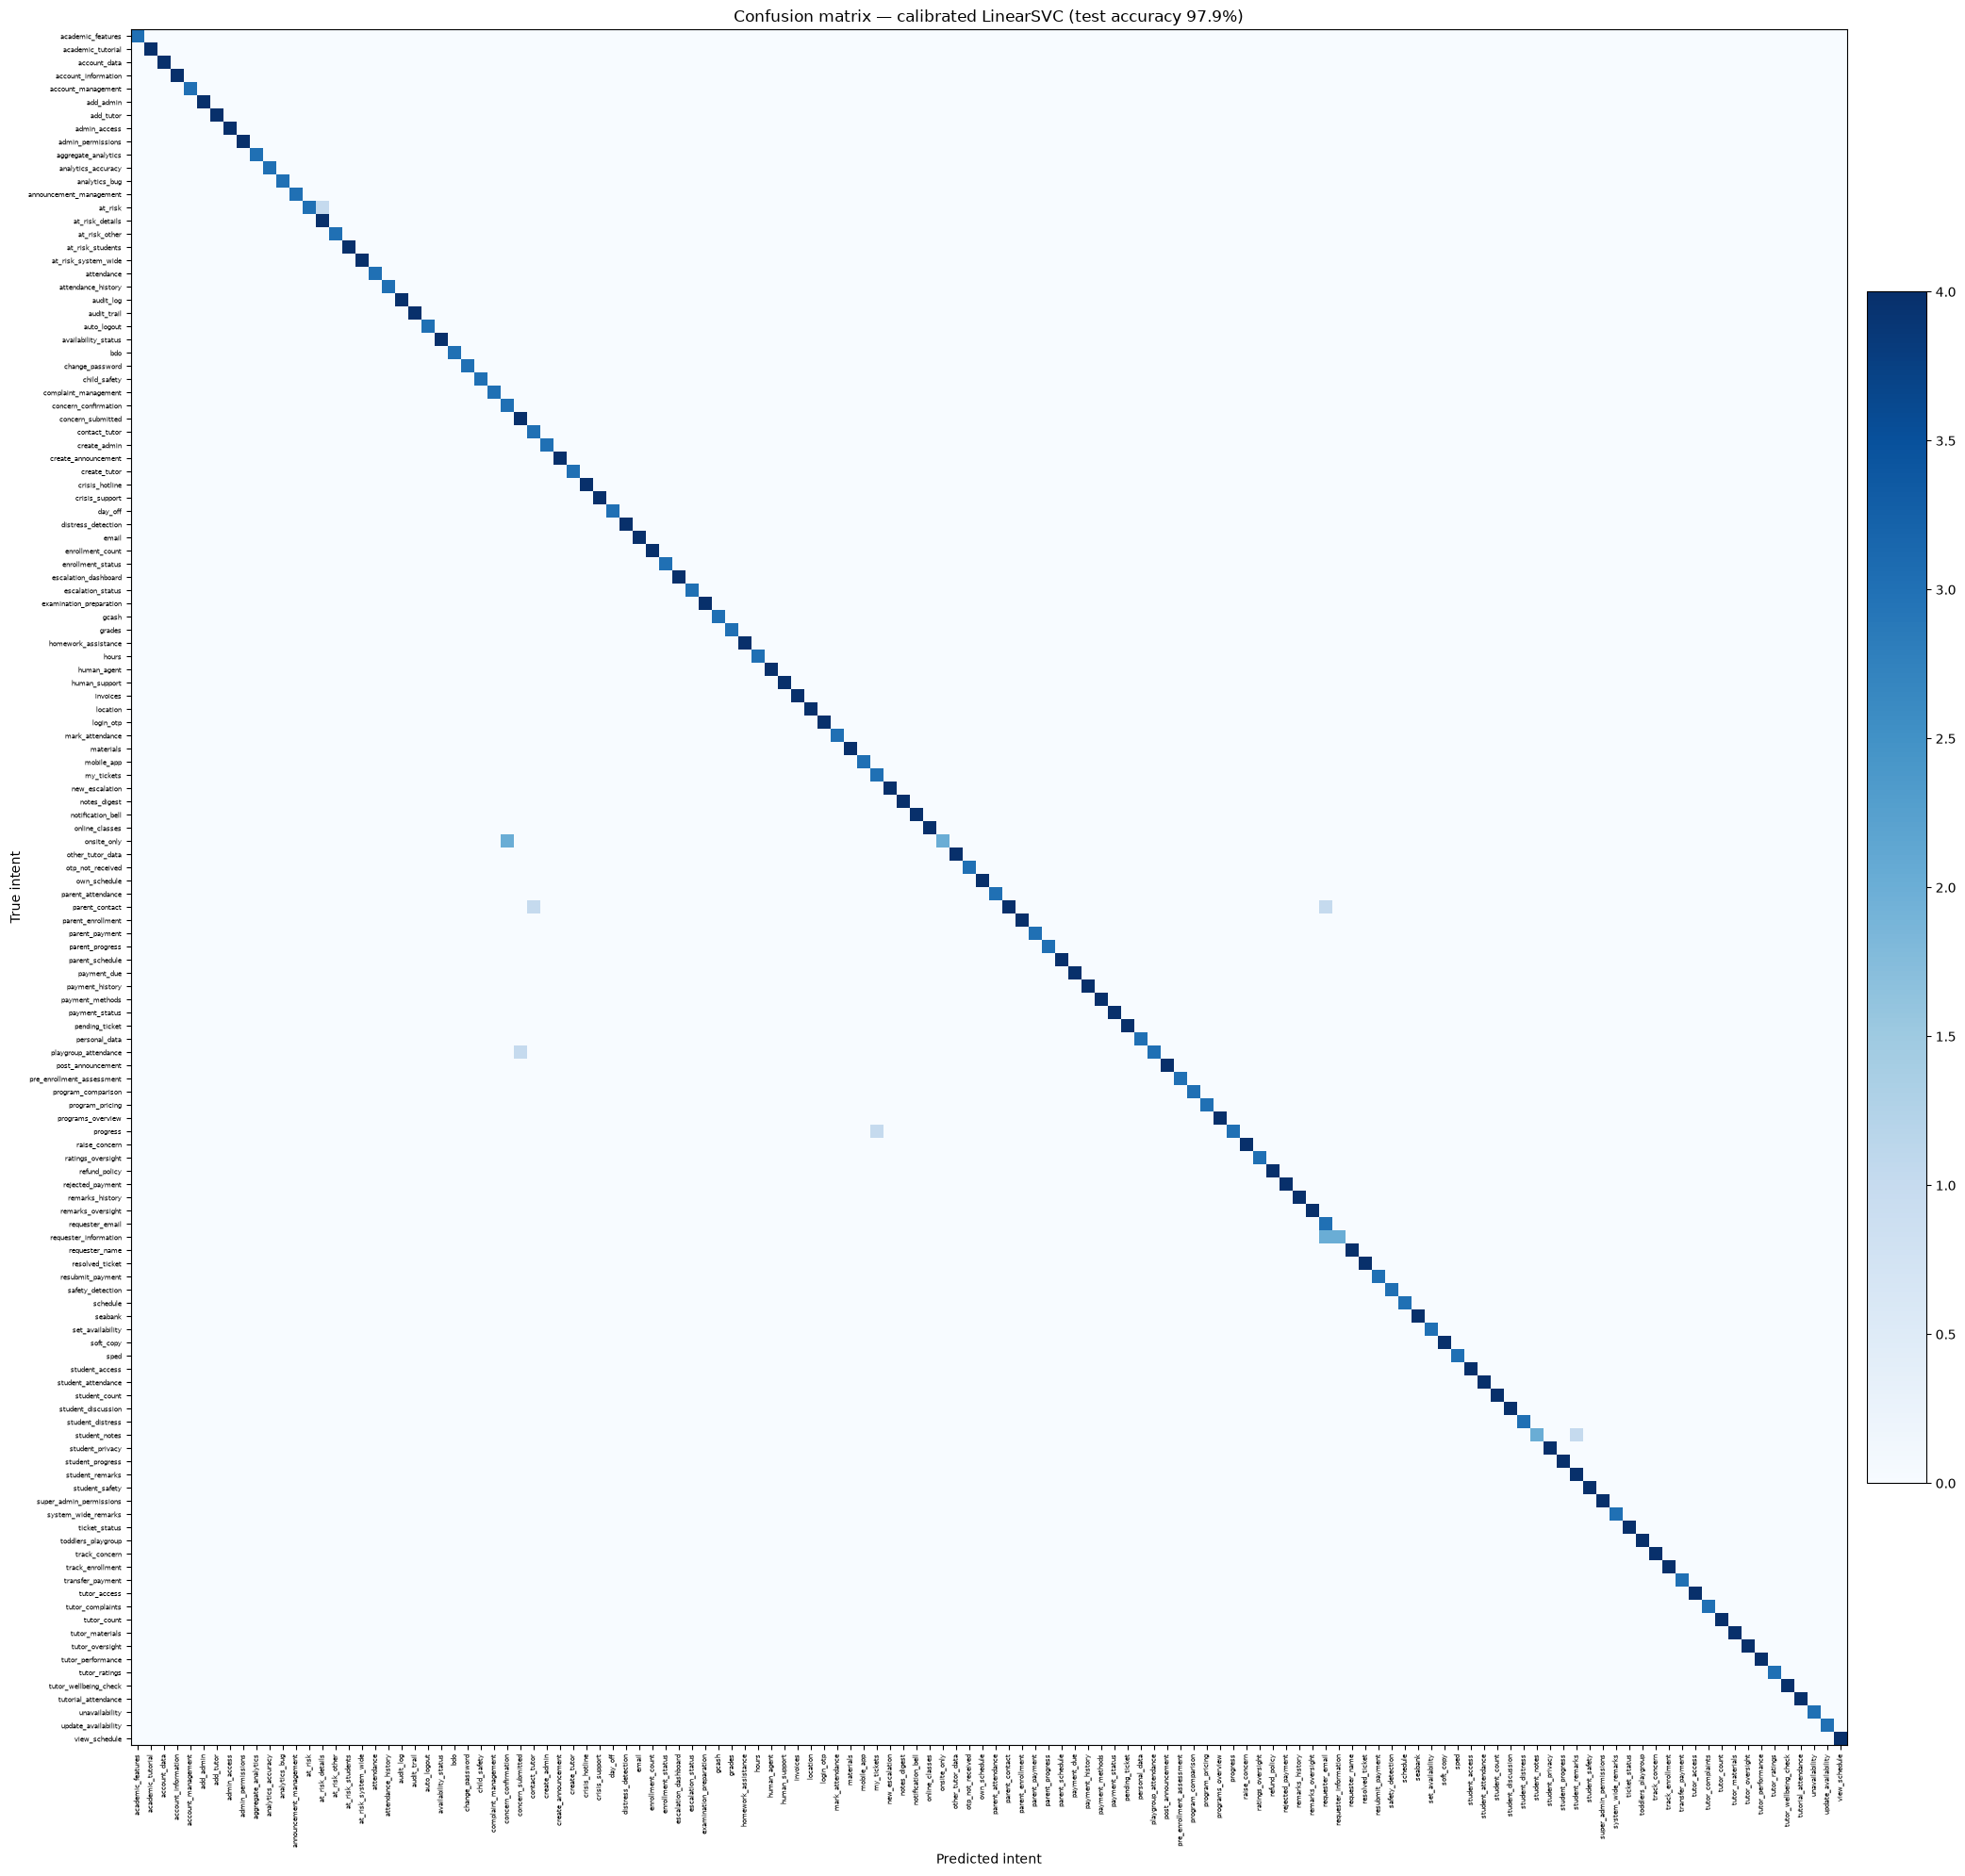

In [10]:

labels_sorted = sorted(df["intent"].unique())
cm = confusion_matrix(y_test, cal_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(22, 20))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)))
ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=90, fontsize=5)
ax.set_yticklabels(labels_sorted, fontsize=5)
ax.set_xlabel("Predicted intent")
ax.set_ylabel("True intent")
ax.set_title(f"Confusion matrix — calibrated LinearSVC (test accuracy {cal_acc:.1%})")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrix.png", dpi=140)
plt.show()


In [11]:

# Every actual misclassification: (true intent, predicted intent, the message, confidence).
test_proba = calibrated_svc.predict_proba(X_test)
class_order = calibrated_svc.classes_
conf = test_proba.max(axis=1)

results = pd.DataFrame({
    "message": X_test_text,
    "true_intent": y_test,
    "predicted_intent": cal_pred,
    "confidence": conf,
})
errors = results[results["true_intent"] != results["predicted_intent"]].sort_values(
    "confidence", ascending=False
)
print(f"{len(errors)} misclassified out of {len(results)} test examples "
      f"({len(errors) / len(results):.1%}).\n")
pd.set_option("display.max_colwidth", 60)
errors[["message", "true_intent", "predicted_intent", "confidence"]]


10 misclassified out of 472 test examples (2.1%).



,message,true_intent,predicted_intent,confidence
431,Why was this student flagged at risk?,at_risk,at_risk_details,0.515117
448,What is the email of Josh's tutor?,parent_contact,requester_email,0.405690
337,Can I message my son Josh's tutor?,parent_contact,contact_tutor,0.362757
274,Please tell me do i need to go to the center??,onsite_only,concern_confirmation,0.262947
45,Do I need to go to the center?,onsite_only,concern_confirmation,0.254771
298,Can I see the remarks written about my students?,student_notes,student_remarks,0.184386
167,Can the admin view requester information?,requester_information,requester_email,0.167055
256,"Paki-explain, can the admin view requester information??",requester_information,requester_email,0.137483
160,Can I see the actual marks I received?,progress,my_tickets,0.122037
192,What happens if a toddler misses Playgroup?,playgroup_attendance,concern_submitted,0.119344


## 7. Choosing the confidence threshold — from the data, not a guess

Part 4 needs a single number: above this confidence, the Node backend trusts the
classifier's predicted intent and routes directly to it; below it, the message falls
back to the existing keyword matcher untouched. The task brief is explicit that this
number should come from testing, not be picked blindly — so here it's derived from the
gap between the confidence of **correct** predictions and **incorrect** ones on the
held-out test set built above.


Confidence distribution — correct vs incorrect predictions:

         count      mean       50%       min       max
correct                                               
False     10.0  0.253159  0.219579  0.119344  0.515117
True     462.0  0.602526  0.641748  0.051090  0.730735


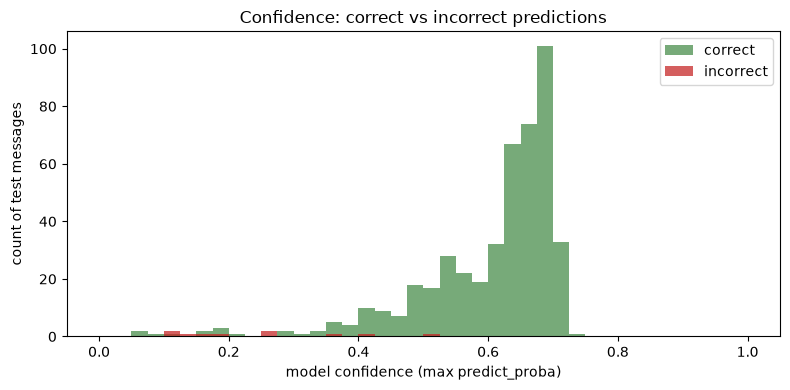

In [12]:

results["correct"] = results["true_intent"] == results["predicted_intent"]

print("Confidence distribution — correct vs incorrect predictions:\n")
print(results.groupby("correct")["confidence"].describe()[["count", "mean", "50%", "min", "max"]])

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
ax.hist(results.loc[results["correct"], "confidence"], bins=bins, alpha=0.65, label="correct", color="#2e7d32")
ax.hist(results.loc[~results["correct"], "confidence"], bins=bins, alpha=0.75, label="incorrect", color="#c62828")
ax.set_xlabel("model confidence (max predict_proba)")
ax.set_ylabel("count of test messages")
ax.set_title("Confidence: correct vs incorrect predictions")
ax.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / "confidence_distribution.png", dpi=110)
plt.show()


In [13]:

# For each candidate threshold: what fraction of test traffic would be trusted
# (>= threshold), and what fraction of THOSE trusted predictions are actually correct
# (precision-if-trusted). We want a threshold where trusted predictions are reliably
# correct, without discarding so much traffic that the classifier stops being useful.
rows = []
for t in np.arange(0.30, 0.96, 0.05):
    trusted = results[results["confidence"] >= t]
    if len(trusted) == 0:
        continue
    precision_if_trusted = trusted["correct"].mean()
    coverage = len(trusted) / len(results)
    rows.append({"threshold": round(t, 2), "coverage": coverage,
                 "precision_if_trusted": precision_if_trusted,
                 "n_trusted": len(trusted)})
threshold_table = pd.DataFrame(rows)
threshold_table


,threshold,coverage,precision_if_trusted,n_trusted
0,0.30,0.959746,0.993377,453
1,0.35,0.953390,0.993333,450
2,0.40,0.932203,0.995455,440
3,0.45,0.889831,0.997619,420
4,0.50,0.836864,0.997468,395
5,0.55,0.739407,1.000000,349
6,0.60,0.652542,1.000000,308
7,0.65,0.442797,1.000000,209
8,0.70,0.072034,1.000000,34


Production messages won't be drawn from this same templated dataset, so treating
this test set's numbers as a hard ceiling and picking a threshold with a safety margin
is more defensible than chasing the loosest cutoff that still clears a bar. So: pick the
**lowest threshold with zero wrong predictions among trusted ones on the held-out set**
(`precision_if_trusted == 1.0`) — a hard guarantee on this data, not just "mostly
right" — and accept the coverage it costs. Falling back below that threshold is not a
failure case: the existing keyword matcher already answers those messages today: this
model only ever adds coverage, never removes it.


In [14]:

TARGET_PRECISION = 1.0
qualifying = threshold_table[threshold_table["precision_if_trusted"] >= TARGET_PRECISION]
CHOSEN_THRESHOLD = (
    float(qualifying["threshold"].min()) if len(qualifying) else float(threshold_table["threshold"].max())
)
row = threshold_table[threshold_table["threshold"] == CHOSEN_THRESHOLD].iloc[0]
permissive = threshold_table.iloc[0]

print(f"Chosen confidence threshold: {CHOSEN_THRESHOLD}")
print(f"  -> at this threshold, {row['precision_if_trusted']:.1%} of trusted predictions "
      f"were correct on the held-out test set (zero wrong),")
print(f"     covering {row['coverage']:.1%} of test traffic "
      f"({int(row['n_trusted'])}/{len(results)} messages).")
print(f"  -> below {CHOSEN_THRESHOLD}, the Node backend falls back to the existing "
      f"keyword matcher untouched (Part 4) — never a wrong answer, just a missed shortcut.")
print()
print(f"For reference, the most permissive threshold tested ({permissive['threshold']}) "
      f"still reached {permissive['precision_if_trusted']:.1%} precision at "
      f"{permissive['coverage']:.1%} coverage — a higher-coverage option if Part 4 "
      f"testing on real traffic shows {CHOSEN_THRESHOLD} is unnecessarily conservative.")


Chosen confidence threshold: 0.55
  -> at this threshold, 100.0% of trusted predictions were correct on the held-out test set (zero wrong),
     covering 73.9% of test traffic (349/472 messages).
  -> below 0.55, the Node backend falls back to the existing keyword matcher untouched (Part 4) — never a wrong answer, just a missed shortcut.

For reference, the most permissive threshold tested (0.3) still reached 99.3% precision at 96.0% coverage — a higher-coverage option if Part 4 testing on real traffic shows 0.55 is unnecessarily conservative.


## 8. Save the trained vectorizer + classifier

Both are needed at inference time: the vectorizer to turn a new message into the same
feature space the classifier was trained on, and the classifier to predict from it.
Saved with `joblib` (the scikit-learn-recommended format for numpy-heavy objects —
faster and more compact than plain `pickle` for this kind of model).

A small `metadata.json` travels alongside them so the Flask service (Part 3) doesn't
have to hardcode the threshold, label list, or model provenance.


In [15]:

joblib.dump(vectorizer, MODELS_DIR / "vectorizer.pkl")
joblib.dump(calibrated_svc, MODELS_DIR / "intent_classifier.pkl")

metadata = {
    "model": "LinearSVC + CalibratedClassifierCV(cv=5)",
    "sklearn_version": sklearn.__version__,
    "trained_at": pd.Timestamp.now("UTC").isoformat(),
    "n_training_examples": int(len(X_train_text)),
    "n_test_examples": int(len(X_test_text)),
    "n_intents": int(df["intent"].nunique()),
    "test_accuracy": float(cal_acc),
    "logistic_regression_test_accuracy": float(logreg_acc),
    "uncalibrated_linear_svc_test_accuracy": float(svc_acc),
    "confidence_threshold": CHOSEN_THRESHOLD,
    "confidence_threshold_precision_on_test": float(row["precision_if_trusted"]),
    "confidence_threshold_coverage_on_test": float(row["coverage"]),
    "labels": labels_sorted,
}
with open(MODELS_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for p in sorted(MODELS_DIR.glob("*")):
    print(" -", p)


Saved:
 - ..\models\class_balance.png
 - ..\models\confidence_distribution.png
 - ..\models\confusion_matrix.png
 - ..\models\intent_classifier.pkl
 - ..\models\metadata.json
 - ..\models\vectorizer.pkl


## Summary

| | |
|---|---|
| Training examples | see cell output above |
| Distinct intents | see cell output above |
| Model shipped | `LinearSVC` wrapped in `CalibratedClassifierCV` — LinearSVC's accuracy with a genuine, well-separated `predict_proba` confidence score (plain LogisticRegression and uncalibrated LinearSVC accuracy reported alongside for comparison) |
| Test accuracy | see §5 |
| Confidence threshold | derived empirically in §7 from the correct-vs-incorrect confidence gap on the held-out test set — **not** guessed |

**Next — Part 3:** wrap `vectorizer.pkl` + `intent_classifier.pkl` in a small Flask
service exposing `POST /predict-intent`, returning `{"intent": ..., "confidence": ...}`.
**Part 4:** call that service from `aiController.js` as an additional signal ahead of
the existing keyword matcher, using the threshold derived above — falling back to the
keyword matcher exactly as it works today whenever confidence is below threshold or the
Python service is unreachable.
